In [1]:
import numpy as np
import xarray as xr
#import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw

import cartopy.crs as ccrs
import cmocean
import matplotlib.ticker as mticker

## Final Decade Average Model Output

Making maps and zonal averages of changes. 

Code for figures 4,5 are shown first. 

Below, we include the code for the Fig S3(?), which includes the North Atlantic and Low latitude forcings. 

In [2]:
# Loading .nc files with the relevant data. 

GlTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Global-4C-O2-Age-Tracers.nc'
GlTr = xr.open_dataset(GlTrnc)

GlPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Global-4C-Physical.nc'
GlTS = xr.open_dataset(GlPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
ThGl = xr.where(GlTS.SALT==0, np.nan, GlTS.THETA).isel(time = np.arange(90,100)).mean('time')
SaGl = xr.where(GlTS.SALT==0, np.nan, GlTS.SALT).isel(time = np.arange(90,100)).mean('time')

o2Gl = xr.where(GlTS.SALT==0, np.nan, GlTr.Oxygen).isel(time = np.arange(90,100)).mean('time')
ageGl = xr.where(GlTS.SALT==0, np.nan, GlTr.Age).isel(time = np.arange(90,100)).mean('time')
# GlTr.Age

In [3]:
PacTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-O2-Age-Tracers.nc'
PacTr = xr.open_dataset(PacTrnc)

PacPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-Physical.nc'
PacTS = xr.open_dataset(PacPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
ThPac = xr.where(GlTS.SALT==0, np.nan, PacTS.THETA).isel(time = np.arange(90,100)).mean('time')
SaPac = xr.where(GlTS.SALT==0, np.nan, PacTS.SALT).isel(time = np.arange(90,100)).mean('time')

o2Pac = xr.where(GlTS.SALT==0, np.nan, PacTr.Oxygen).isel(time = np.arange(90,100)).mean('time')
agePac = xr.where(GlTS.SALT==0, np.nan, PacTr.Age).isel(time = np.arange(90,100)).mean('time')


In [4]:
SOTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-O2-Age-Tracers.nc'
SOTr = xr.open_dataset(SOTrnc)

SOPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-Physical.nc'
SOTS = xr.open_dataset(SOPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
ThSO = xr.where(GlTS.SALT==0, np.nan, SOTS.THETA).isel(time = np.arange(90,100)).mean('time')
SaSO = xr.where(GlTS.SALT==0, np.nan, SOTS.SALT).isel(time = np.arange(90,100)).mean('time')

o2SO = xr.where(GlTS.SALT==0, np.nan, SOTr.Oxygen).isel(time = np.arange(90,100)).mean('time')
ageSO = xr.where(GlTS.SALT==0, np.nan, SOTr.Age).isel(time = np.arange(90,100)).mean('time')


In [5]:
#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
conTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Age-Tracers.nc'
conTr = xr.open_dataset(conTrnc)

conPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
conTS = xr.open_dataset(conPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
Thcon = xr.where(GlTS.SALT==0, np.nan, conTS.THETA).isel(time = np.arange(90,100)).mean('time')
Sacon = xr.where(GlTS.SALT==0, np.nan, conTS.SALT).isel(time = np.arange(90,100)).mean('time')

o2con = xr.where(GlTS.SALT==0, np.nan, conTr.Oxygen).isel(time = np.arange(90,100)).mean('time')
agecon = xr.where(GlTS.SALT==0, np.nan, conTr.Age).isel(time = np.arange(90,100)).mean('time')


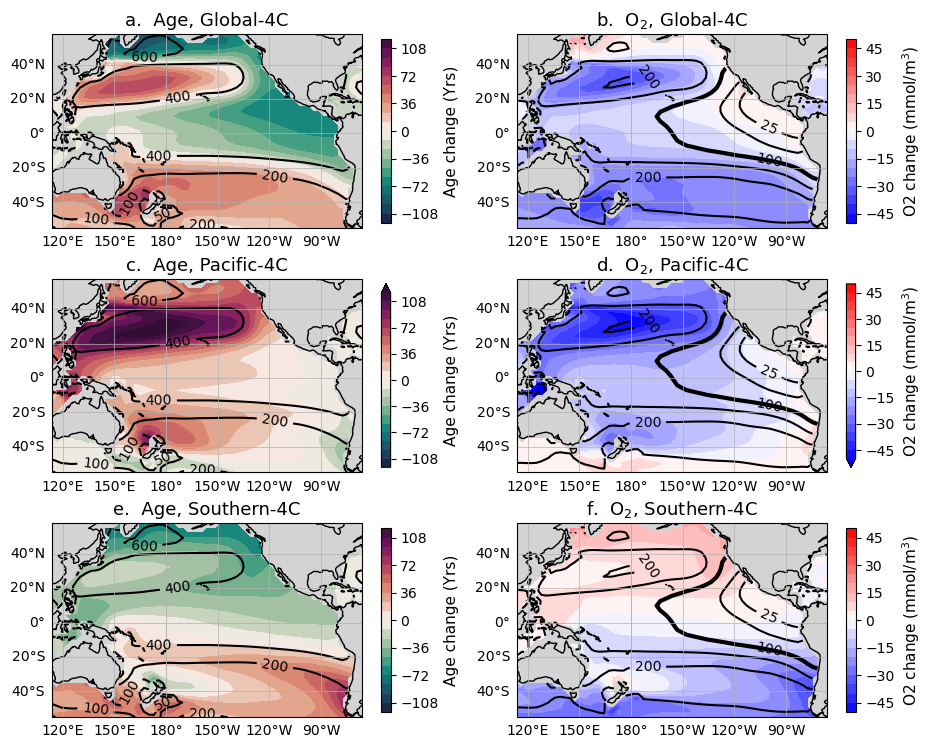

In [36]:
## Age and oxygen mapping (Figure 4). 


#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))
xran = range(40,105)
yran = range(12,53)
zran = range(8,13)

#SOTr = SOfadeTr
deps = SOTr.drF.isel(Z=zran)*SOTr.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpSO = o2SO.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpPac = o2Pac.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpGl = o2Gl.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
#tmpNA = o2NA.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmp0 = o2con.isel(XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 

PlSOo = tmpSO.sum('Z')/deps.sum('Z')
PlPaco = tmpPac.sum('Z')/deps.sum('Z')
PlGlo = tmpGl.sum('Z')/deps.sum('Z')
#PlNA = tmpNA.sum('Z')/deps.sum('Z')
Pl0o = tmp0.sum('Z')/deps.sum('Z')

vm = 50

o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]
o2levels00 =[25, 50, 100, 150, 200, 250] 
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(3, 2, figsize=(11, 9), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row


#vm = 120
#agelevels = [50, 100, 200, 400, 800, 1200, 1600 ]
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

Diag3d = PacTr

cbarshr = 0.9
o2map = 'bwr'


# Contourf plot with Cartopy (left subplot)
A = axs[0,1].contourf(
    Diag3d.XC[xran],
    Diag3d.YC[yran],
    1000*(PlGlo - Pl0o),
    vmin=-vm,
    vmax=vm,
    levels=np.linspace(-vm, vm, 21),
    cmap=o2map,
    extend='neither',
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbAo = plt.colorbar(A, ax=axs[0,1], orientation='vertical', pad=0.05, shrink=cbarshr)

cbAo.set_label('O2 change (mmol/m$^3$)', fontsize=11)

B = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*(PlPaco- Pl0o), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = o2map, extend='min', transform=ccrs.PlateCarree())
cbBo = plt.colorbar(B, ax= axs[1,1], pad=0.05, shrink=cbarshr)
cbBo.set_label('O2 change (mmol/m$^3$)', fontsize=11)


C = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*(PlSOo- Pl0o), vmin = -vm, vmax = vm, 
                      levels = np.linspace(-vm, vm,21), cmap = o2map, transform=ccrs.PlateCarree())
cbCo = plt.colorbar(C, ax= axs[2,1], pad=0.05, shrink=cbarshr)
cbCo.set_label('O2 change (mmol/m$^3$)', fontsize=11)

# to add a bold contour just around the ETP OMZ, we need to exclude the subpolar NP patch that has O2<100. 
tmpo = np.array(Pl0o)
# at XC = 27, there Pl0o > 100 mmol/m^3 everywhere. 
# use this value to fill the western half, avoiding subpolar NP patch that's <100 
tmpo[:, 0:27] = np.transpose(np.tile(tmpo[:, 27],[27, 1]))
fixPl0o = xr.DataArray(tmpo, dims = Pl0o.dims, coords = Pl0o.coords)

j=1
for i in range(3):
    cl = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], 1000*Pl0o, colors= 'k', levels = o2levels00,transform=ccrs.PlateCarree())
    cl.clabel(levels = [25, 100, 200])
    cl2 = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], 1000*fixPl0o, colors= 'k',linewidths = 3, levels = [-100,100],transform=ccrs.PlateCarree())
    axs[i,j].grid()
    axs[i,j].coastlines()
    gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    axs[i,j].set_facecolor('lightgray')
    #axs[i,j].text(0.05, 0.96, lets[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

       

axs[0,1].set_title('b.  O$_2$, Global-4C', fontsize=13)
axs[1,1].set_title('d.  O$_2$, Pacific-4C', fontsize=13)
axs[2,1].set_title('f.  O$_2$, Southern-4C', fontsize=13)


agemap = cmocean.cm.curl
agemap.set_bad(color='black')


vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]


cbarshr = 0.9



# weighting by depth bin 
tmpSO = ageSO.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpPac = agePac.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpGl = ageGl.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
#tmpNA = ageNA.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmp0 = agecon.isel(XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 

PlSO = tmpSO.sum('Z')/deps.sum('Z')
PlPac = tmpPac.sum('Z')/deps.sum('Z')
PlGl = tmpGl.sum('Z')/deps.sum('Z')
#PlNAo = tmpNA.sum('Z')/deps.sum('Z')
Pl0 = tmp0.sum('Z')/deps.sum('Z')

# Contourf plot with Cartopy (left subplot)
A = axs[0,0].contourf(
    Diag3d.XC[xran],
    Diag3d.YC[yran],
    PlGl - Pl0,
    vmin=-vm,
    vmax=vm,
    levels=np.linspace(-vm, vm, 21),
    cmap=agemap,
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbAa = plt.colorbar(A, ax=axs[0,0], orientation='vertical', pad=0.05, shrink=cbarshr)
cbAa.set_label('Age change (Yrs)', fontsize=11)



B = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlPac- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend='max', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbBa = plt.colorbar(B, ax= axs[1,0], pad=0.05, shrink=cbarshr)
cbBa.set_label('Age change (Yrs)', fontsize=11)

C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlSO- Pl0, vmin = -vm, vmax = vm, 
                      levels = np.linspace(-vm, vm,21), cmap = agemap, transform=ccrs.PlateCarree())
cbCa = plt.colorbar(C, ax= axs[2,0], pad=0.05, shrink=cbarshr)
cbCa.set_label('Age change (Yrs)', fontsize=11)


j=0
for i in range(3):
    cl = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = agelevels,transform=ccrs.PlateCarree())
    cl.clabel()
    axs[i,j].grid()
    axs[i,j].coastlines()
    gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    axs[i,j].set_facecolor('lightgray')
    #axs[i,j].text(0.05, 0.96, lets[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

        #axs[i,j].text(0.05, 0.9, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')
        

axs[0,0].set_title('a.  Age, Global-4C', fontsize=13)
axs[1,0].set_title('c.  Age, Pacific-4C', fontsize=13)
axs[2,0].set_title('e.  Age, Southern-4C', fontsize=13)
#axs[1,1].set_title('NAtlantic-4C', fontsize=14)

#plt.show()

#plt.savefig('../eps_figures/AgeO2maps4-30.eps', bbox_inches="tight")

#plt.show()

In [35]:
## AOU calculations; note this value is actually -1*AOU. 

aouSO = o2SO - 0.001*gsw.O2sol(SaSO, ThSO, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aouPac = o2Pac - 0.001*gsw.O2sol(SaPac, ThPac, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aouGl = o2Gl - 0.001*gsw.O2sol(SaGl, ThGl, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aou0 = o2con - 0.001*gsw.O2sol(Sacon, Thcon, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)

#aouNA = o2NA - 0.001*gsw.O2sol(SaNA, THNA, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)

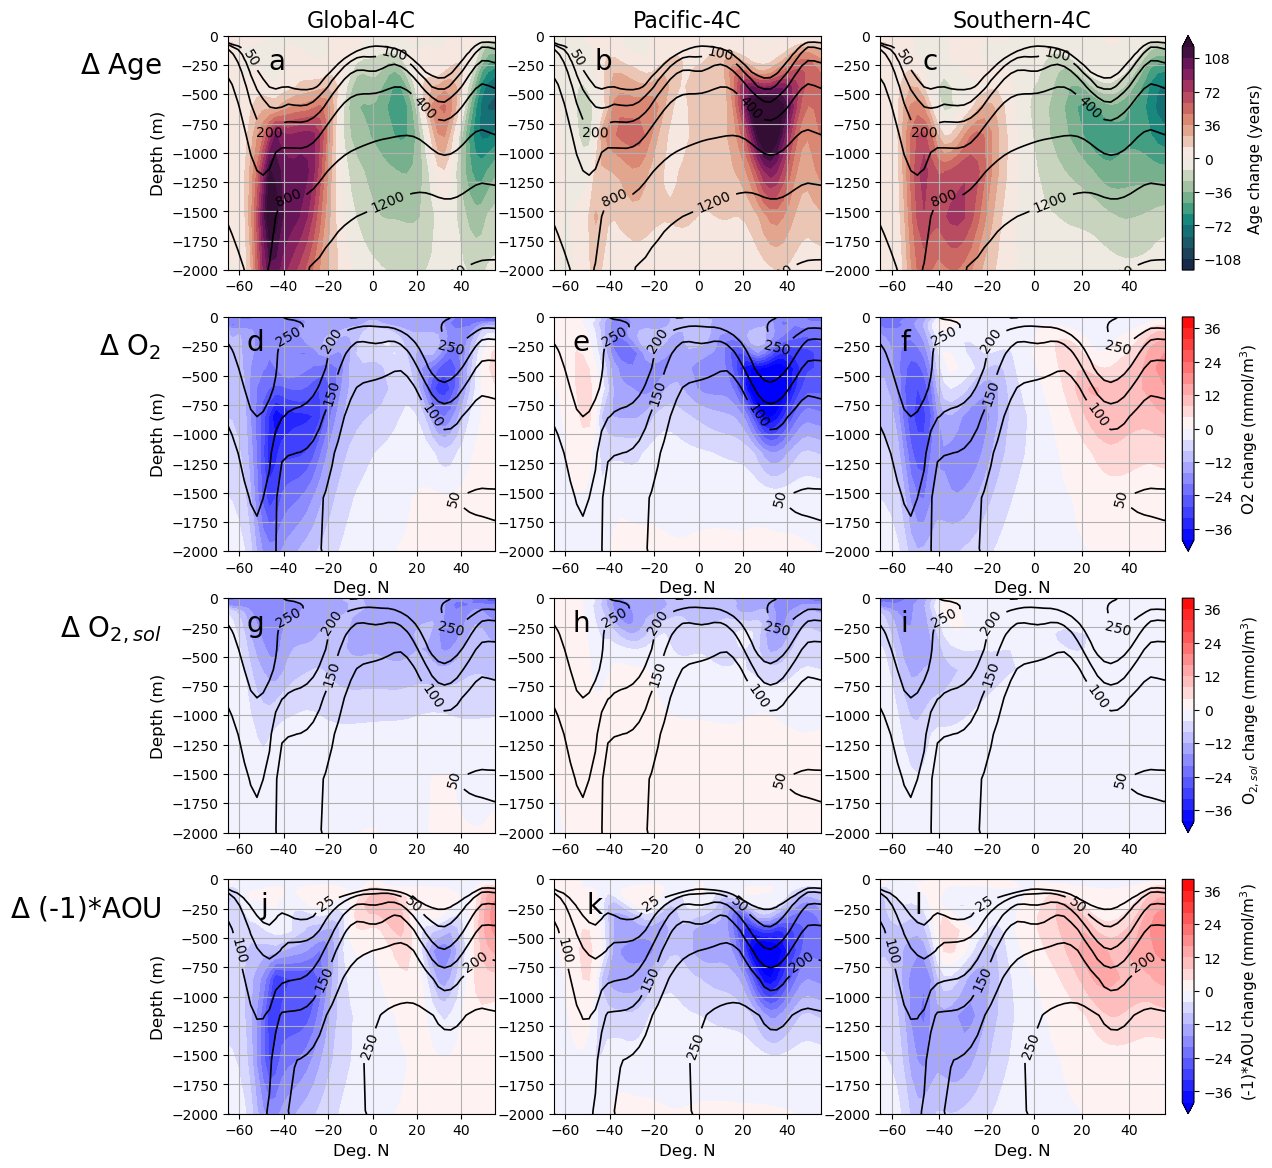

In [66]:
# Figure 5 (zonal means!) 

# 3x4 plots to show depth distribution of changes 

widths = [0.3, 0.3, 0.4]
fig, axs = plt.subplots(ncols=3 , nrows = 4,figsize=(13,14), gridspec_kw={'width_ratios': widths})
xran = range(64,80)
yran = range(8,53)
zran = range(17)

# direct average is OK because the grid size is uniform in longitude 
# O2 means
PlSO = o2SO.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlPac = o2Pac.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlGl = o2Gl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = o2con.isel(XC = xran, YC = yran, Z= zran).mean('XC')

# actually -1*AOU
PlaSO = aouSO.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaPac = aouPac.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaGl = aouGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pla0 = aou0.isel(XC = xran, YC = yran, Z= zran).mean('XC')

vm = 40 # max value for O2, AOU change

# age
PlageSO = ageSO.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlagePac = agePac.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlageGl = ageGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Plage0 = agecon.isel(XC = xran, YC = yran, Z= zran).mean('XC')


vma = 120 # max value for age change
#vm2 = 0
agemap = cmocean.cm.curl
agelevels = [50, 100, 200, 400, 800, 1200, 1600]

Diag3d = SOTr
lw=1.2

A = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageGl-Plage0  , vmin = -vma, vmax = vma, extend='max', levels = np.linspace(-vma, vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[0,0])
axs[0,0].set_ylim([-2000,0])
cl0 = axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl0.clabel()
axs[0,0].grid()

B = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlagePac-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma, vma,21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[0,1])
axs[0,1].set_ylim([-2000,0])
cl1 = axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl1.clabel()
axs[0,1].grid()

M = axs[0,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageSO-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma,vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(M, ax= axs[0,2])
Mcb.set_label('Age change (years)', fontsize= 11)
axs[0,2].set_ylim([-2000,0])
cl2 = axs[0,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl2.clabel()
axs[0,2].grid()




o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]
o2levels = [1000*k for k in o2levels]
#[element * 1000 for element in original_list]

Diag3d = SOTr

# Oxygen here

A = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlGl - Pl0)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[1,0])
axs[1,0].set_ylim([-2000,0])
cl3 = axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0*1000, colors= 'k', levels = o2levels, linewidths=lw)
cl3.clabel()
axs[1,0].grid()

B = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[1,1])
axs[1,1].set_ylim([-2000,0])
cl4 = axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl4.clabel()
axs[1,1].grid()

C = axs[1,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbC = plt.colorbar(C, ax= axs[1,2])
cbC.set_label('O2 change (mmol/m$^3$)', fontsize=11)
axs[1,2].set_ylim([-2000,0])
cl5 = axs[1,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl5.clabel() 
axs[1,2].grid()

## Solubility here! Computed from difference of (-1)*AOU and O2 here. 

D = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlGl - Pl0 - PlaGl+ Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[2,0].set_ylim([-2000,0])
cl6 = axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl6.clabel()
axs[2,0].grid()

E = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0 - PlaPac+ Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[2,1].set_ylim([-2000,0])
cl7 = axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl7.clabel()
axs[2,1].grid()

F = axs[2,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0 - PlaSO+Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[2,2])
cbF.set_label('O$_{2,sol}$ change (mmol/m$^3$)', fontsize=11) 
axs[2,2].set_ylim([-2000,0])
cl8 = axs[2,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl8.clabel() 
axs[2,2].grid()

## AOU here

D = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlaGl- Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[3,0].set_ylim([-2000,0])
cl6 = axs[3,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl6.clabel()
axs[3,0].grid()

E = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaPac-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[3,1].set_ylim([-2000,0])
cl7 = axs[3,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl7.clabel()
axs[3,1].grid()

F = axs[3,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaSO-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[3,2])
cbF.set_label('(-1)*AOU change (mmol/m$^3$)', fontsize=11) 
axs[3,2].set_ylim([-2000,0])
cl8 = axs[3,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl8.clabel() 
axs[3,2].grid()

axs[0,0].set_title('Global-4C', fontsize = 16)
axs[0,1].set_title('Pacific-4C', fontsize = 16)
axs[0,2].set_title('Southern-4C', fontsize = 16)

axs[3,0].set_xlabel('Deg. N', fontsize=12) 
axs[3,1].set_xlabel('Deg. N', fontsize=12) 
axs[3,2].set_xlabel('Deg. N', fontsize=12) 

axs[1,0].set_xlabel('Deg. N', fontsize=12) 
axs[1,1].set_xlabel('Deg. N', fontsize=12) 
axs[1,2].set_xlabel('Deg. N', fontsize=12) 

#axs[0,0].set_ylabel('Age Change', fontsize = 12)
#axs[1,0].set_ylabel('O$_2$ Change', fontsize=12)
#axs[2,0].set_ylabel('O$_2$ Solubility Change', fontsize=12)
#axs[3,0].set_ylabel('(-1)*AOU Change', fontsize=12)

letters = ['a','b','c','d','e','f','g','h','i', 'j', 'k', 'l']
x_loc = [0.15,0.07,0.07,0.12] # where to place the labels. 
for i in range(4):
    axs[i,0].set_ylabel('Depth (m)', fontsize = 12)
    for j in range(3):
        axs[i,j].text(x_loc[i], 0.95, letters[3*i+j], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].set_xlim([-65,55])

rows = ['$\Delta$ Age', '$\Delta$ O$_2$', '$\Delta$ O$_{2,sol}$', '$\Delta$ (-1)*AOU']

for ax, row_label in zip(axs[:,0], rows):
    ax.annotate(row_label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad+12, 57),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size=20, ha='right', va='baseline', rotation=0)

#axs[3,1].text(0.1, 0.9, 'h', fontsize=20, transform=axs[3,1].transAxes, ha='left', va='top')

#axs[1,1].set_title('Pac 4Cstep + SO 4Cstep')


#plt.savefig('o2_aou_sections_7-9.eps')

plt.savefig('../eps_figures/age_o2_aou_sections5-23.eps', bbox_inches="tight")
#plt.show()


In [69]:
## Figure S4: North Atlantic and Low Latitude forcing

# First, load data for North Atlantic 

NATrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/NAtlantic-4C-O2-Age-Tracers.nc'
NATr = xr.open_dataset(NATrnc)

NAPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/NAtlantic-4C-Physical.nc'
NATS = xr.open_dataset(NAPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
ThNA = xr.where(GlTS.SALT==0, np.nan, NATS.THETA).isel(time = np.arange(90,100)).mean('time')
SaNA = xr.where(GlTS.SALT==0, np.nan, NATS.SALT).isel(time = np.arange(90,100)).mean('time')

o2NA = xr.where(GlTS.SALT==0, np.nan, NATr.Oxygen).isel(time = np.arange(90,100)).mean('time')
ageNA = xr.where(GlTS.SALT==0, np.nan, NATr.Age).isel(time = np.arange(90,100)).mean('time')


# Next, Low Latitude forcing

LLTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/LowLat-4C-O2-Age-Tracers.nc'
LLTr = xr.open_dataset(LLTrnc)

LLPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/LowLat-4C-Physical.nc'
LLTS = xr.open_dataset(LLPhnc)
#GlPhnc = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')

#temperature, masked where salinity =0 (i.e. land)
ThLL = xr.where(GlTS.SALT==0, np.nan, LLTS.THETA).isel(time = np.arange(90,100)).mean('time')
SaLL = xr.where(GlTS.SALT==0, np.nan, LLTS.SALT).isel(time = np.arange(90,100)).mean('time')

o2LL = xr.where(GlTS.SALT==0, np.nan, LLTr.Oxygen).isel(time = np.arange(90,100)).mean('time')
ageLL = xr.where(GlTS.SALT==0, np.nan, LLTr.Age).isel(time = np.arange(90,100)).mean('time')


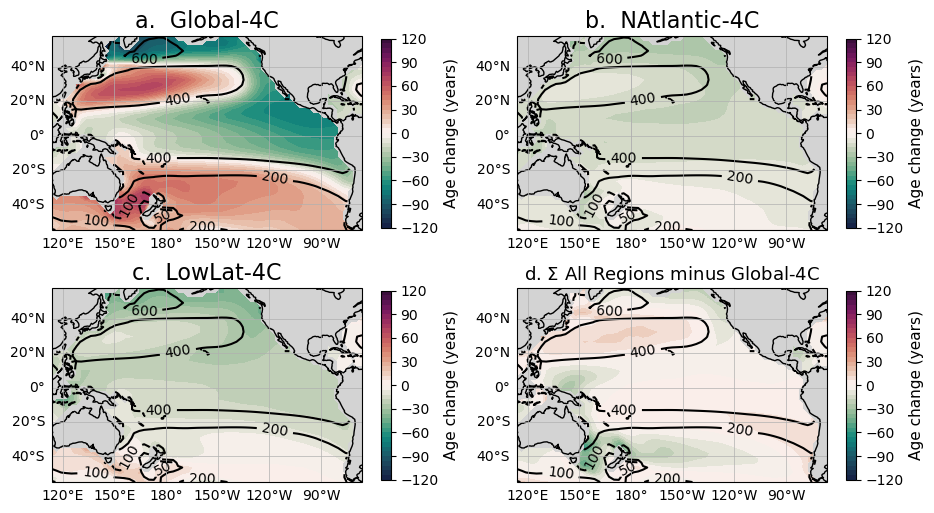

In [77]:
## Figure S4: Global, NAtlantic, LowLat, and difference of all combined regions.

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(2, 2, figsize=(11, 6), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
nlev = 41
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

Diag3d = PacTr

cbarshr = 0.9

xran = range(40,105)
yran = range(12,53)
zran = range(8,13)

#PlSO = ageSO.isel( XC = xran, YC = yran, Z= zran).mean('Z')
deps = SOTr.drF.isel(Z=zran)*SOTr.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpSO = ageSO.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran)
tmpLL = ageLL.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpPac = agePac.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpGl = ageGl.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpNA = ageNA.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmp0 = agecon.isel(XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 

PlSO = tmpSO.sum('Z')/deps.sum('Z')
PlLL = tmpLL.sum('Z')/deps.sum('Z')
PlPac = tmpPac.sum('Z')/deps.sum('Z')
PlGl = tmpGl.sum('Z')/deps.sum('Z')
PlNA = tmpNA.sum('Z')/deps.sum('Z')
Pl0 = tmp0.sum('Z')/deps.sum('Z')



# Contourf plot with Cartopy (left subplot)
A = axs[0,0].contourf(
    Diag3d.XC[xran],
    Diag3d.YC[yran],
    PlGl - Pl0,
    vmin=-vm,
    vmax=vm,
    levels=np.linspace(-vm, vm, nlev),
    cmap=agemap,
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbA = plt.colorbar(A, ax= axs[0,0], pad=0.05, shrink=cbarshr)
cbA.set_label('Age change (years)', fontsize=11)



B = axs[0,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlNA- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,nlev), cmap = agemap, transform=ccrs.PlateCarree())
cbB = plt.colorbar(B, ax= axs[0,1], pad=0.05, shrink=cbarshr)
cbB.set_label('Age change (years)', fontsize=11)


C = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlLL- Pl0, vmin = -vm, vmax = vm, 
                      levels = np.linspace(-vm, vm,nlev), cmap = agemap, transform=ccrs.PlateCarree())
cbC = plt.colorbar(C, ax= axs[1,0], pad=0.05, shrink=cbarshr)
cbC.set_label('Age change (years)', fontsize=11)



D = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlLL+PlNA+PlPac+PlSO - PlGl - 3*Pl0, vmin = -vm, vmax = vm,
                      levels = np.linspace(-vm, vm,nlev), cmap = agemap, transform=ccrs.PlateCarree())
cbD = plt.colorbar(D, ax= axs[1,1], pad=0.05, shrink=cbarshr)
cbD.set_label('Age change (years)', fontsize=11)


import matplotlib.ticker as mticker
#lets = ['a','b','c','d']
for i in range(2):
    for j in range(2):
        # adding background contours
        cl = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = agelevels,transform=ccrs.PlateCarree())
        cl.clabel()
        axs[i,j].grid()
        axs[i,j].coastlines()
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
        axs[i,j].set_facecolor('lightgray')
        #axs[i,j].text(0.05, 0.95, lets[2*i+j], fontsize=17, transform=axs[i,j].transAxes, ha='left', va='top')

        #axs[i,j].text(0.05, 0.9, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')
        
axs[0,0].set_title('a.  Global-4C', fontsize=16)
axs[0,1].set_title('b.  NAtlantic-4C', fontsize=16)
axs[1,0].set_title('c.  LowLat-4C', fontsize=16)
axs[1,1].set_title('d. $\\Sigma$ All Regions minus Global-4C', fontsize=13)

plt.savefig('../eps_figures/SuppLL_523.eps', bbox_inches="tight")
#plt.show()
